# 01 — Data Preparation, EDA & BiLSTM Baseline

**E-commerce Review Sentiment & CS Flagging System**

This notebook covers:

- **Phase 1 — Data Preparation & EDA:** download `amazon_polarity`, explore it, clean it, build a balanced
  20,000-review dataset (10k Positive / 10k Negative) and a stratified Train / Validation / Test split.
  The **test split is saved once and reused by every model** so the benchmark is fair.
- **Phase 2 — BiLSTM baseline:** custom vocabulary, padding, `BiLSTM` (hidden 128, 2 layers, dropout 0.5),
  a PyTorch training loop and checkpointing of the lowest validation loss to `models/bilstm_best.pt`.

All paths and hyperparameters live in `src/config.py`; reusable code lives in `src/`.

## 0. Setup

In [1]:
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ndchien2004/ecommerce-sentiment-analyzer.git"


def find_repo_root() -> Path:
    """Use the local repo if we are inside it, otherwise (e.g. Kaggle) clone it."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "src" / "config.py").exists():
            return candidate
    target = Path.cwd() / "ecommerce-sentiment-analyzer"
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
    return target


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repo root:", ROOT)

Repo root: D:\E-commerce Review Sentiment & CS Flagging System


In [2]:
import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Image, display
from torch import nn
from torch.utils.data import DataLoader

from src import config
from src.data_utils import (
    EMOJI_RE,
    HTML_TAG_RE,
    URL_RE,
    PadCollator,
    ReviewDataset,
    Vocabulary,
    balance_dataset,
    clean_text,
    get_device,
    load_raw_dataset,
    preprocess_dataframe,
    save_splits,
    set_seed,
    split_dataset,
    tokenize,
)
from src.evaluation import evaluate_predictor
from src.inference import analyze_review
from src.model_bilstm import BiLSTM, evaluate, save_checkpoint, train_one_epoch

set_seed(config.SEED)
device = get_device()
sns.set_theme(style="whitegrid")
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"PyTorch {torch.__version__} | device: {device} | seed: {config.SEED}")

PyTorch 2.11.0+cu128 | device: cuda | seed: 42


# Phase 1 — Data Preparation & EDA

## 1. Load the raw data

`amazon_polarity` is loaded with Hugging Face `datasets`. To keep the download small we only read one of the
four training parquet shards (~900k reviews), which is far more than the 20k we need.
Each review's **title** and **body** are joined, since the title often carries the strongest sentiment cue.

In [3]:
raw_df = load_raw_dataset()
print(f"Raw reviews: {len(raw_df):,}")
raw_df.head()

Raw reviews: 900,000


,text,label
0,Stuning even for the non-gamer. This sound tra...,1
1,The best soundtrack ever to anything.. I'm rea...,1
2,Amazing!. This soundtrack is my favorite music...,1
3,Excellent Soundtrack. I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...",1


## 2. Exploratory Data Analysis

### 2.1 Label distribution

In [4]:
raw_df["sentiment"] = raw_df["label"].map(config.ID2LABEL)
label_counts = raw_df["sentiment"].value_counts()
pd.DataFrame({"count": label_counts, "share": (label_counts / len(raw_df)).round(4)})

,count,share
sentiment,,
Positive,454514,0.505
Negative,445486,0.495


### 2.2 Review length (words)

In [5]:
raw_df["n_words"] = raw_df["text"].str.split().str.len()
raw_df.groupby("sentiment")["n_words"].describe(percentiles=[0.5, 0.9, 0.99]).round(1)

,count,mean,std,min,50%,90%,99%,max
sentiment,,,,,,,,
Negative,445486.0,82.4,42.7,2.0,75.0,147.0,182.0,241.0
Positive,454514.0,76.4,43.2,2.0,67.0,143.0,181.0,222.0


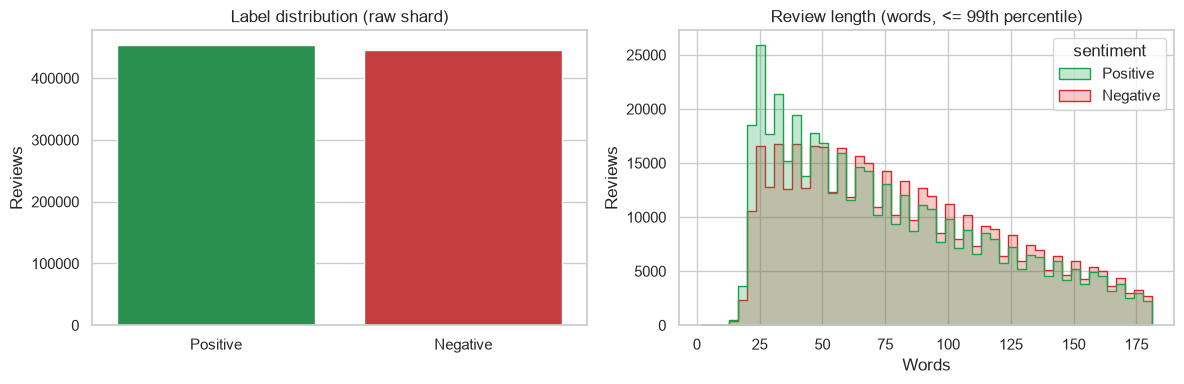

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index,
            palette={"Negative": "#dc2626", "Positive": "#16a34a"}, legend=False, ax=axes[0])
axes[0].set(title="Label distribution (raw shard)", xlabel="", ylabel="Reviews")

clip = raw_df["n_words"].quantile(0.99)
sns.histplot(data=raw_df[raw_df["n_words"] <= clip], x="n_words", hue="sentiment", bins=50,
             palette={"Negative": "#dc2626", "Positive": "#16a34a"}, element="step", ax=axes[1])
axes[1].set(title="Review length (words, <= 99th percentile)", xlabel="Words", ylabel="Reviews")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "eda_raw_distribution.png", dpi=150)
plt.show()

### 2.3 Noise in the text

How often do reviews contain things our cleaning step has to handle?

In [7]:
text = raw_df["text"]
noise = pd.Series({
    "HTML tags": text.str.contains(HTML_TAG_RE).mean(),
    "HTML entities (&amp; ...)": text.str.contains(r"&(?:[a-z]+|#\d+);", regex=True).mean(),
    "URLs": text.str.contains(URL_RE).mean(),
    "Emojis": text.str.contains(EMOJI_RE).mean(),
    "Uppercase letters": text.str.contains(r"[A-Z]", regex=True).mean(),
    "Repeated whitespace": text.str.contains(r"\s{2,}", regex=True).mean(),
})
(noise * 100).round(3).to_frame("% of reviews")

,% of reviews
HTML tags,0.054
HTML entities (&amp; ...),0.063
URLs,0.152
Emojis,0.001
Uppercase letters,97.954
Repeated whitespace,0.000


### 2.4 Sample reviews

In [8]:
for label, name in config.ID2LABEL.items():
    print(f"=== {name} ===")
    for review in raw_df.loc[raw_df["label"] == label, "text"].sample(3, random_state=config.SEED):
        print("•", review[:300], "\n")

=== Negative ===
• 1 good song. the title track is what made me buy this album, the rest of the album sounds nothing like that song and i was very disappointed. 

• 'Wise,' but debatably 'Quaker'. Appreciate the stories told by this author about his life and consider the insights that he has gained from reflection on his experience; but, please, do not base your understanding of Quakerism on his presentation. In spite of the fact that Smith is a lifelong Friend 

• Don't buy!. I bought this product in hopes it would smell as amazing as the deotorant and be warned it smells nothing like it! I threw it away after realizing how awful it smelled... 

=== Positive ===


• Life happens. Romantic Comedy about the human condition and youth. Great scenery, makes you want to vist Italy. Where's the DVD of this? 

• Finzi wrote the best clarinet concerto ever !. As a collector of clarinet concerto's, this is my favourite concerto. This Naxos cd is extreme value for money ! We hand them out as business gifts and everybody likes the cd very much, 

• Will you be left behind?. There has been much speculation about end times, when will the Rapture occur, who is the antichrist and a whole host of other issues. Left Behind is a skillful dramatization of what the end times might be like and what the consequences of the Rapture might be for those that 



## 3. Cleaning

`clean_text` (in `src/data_utils.py`) is shared by training, evaluation and the app:

1. Unescape HTML entities and strip HTML tags.
2. Remove URLs.
3. **Emoji strategy:** sentiment-bearing emojis become words (😍 → `love`, 😡 → `angry`, 👍 → `good`);
   all other emojis are removed. Amazon reviews rarely contain emojis, but user input in the app might.
4. Lowercase.
5. Collapse repeated whitespace.

Then empty and duplicated reviews are dropped.

In [9]:
demo = [
    "Great <br />product!!   Works   PERFECTLY 😍👍",
    "Total SCAM &amp; broken on arrival 😡 see http://example.com/item",
    "  Meh.\n\nIt's OK 🚀 I guess  ",
]
pd.DataFrame({"raw": demo, "clean": [clean_text(t) for t in demo]})

,raw,clean
0,Great <br />product!! Works PERFECTLY 😍👍,great product!! works perfectly love good
1,Total SCAM &amp; broken on arrival 😡 see http:...,total scam & broken on arrival angry see
2,Meh.\n\nIt's OK 🚀 I guess,meh. it's ok i guess


In [10]:
start = time.time()
clean_df = preprocess_dataframe(raw_df[["text", "label"]])
print(f"Cleaned in {time.time() - start:.0f}s: {len(raw_df):,} -> {len(clean_df):,} reviews "
      f"({len(raw_df) - len(clean_df):,} empty/duplicate rows removed)")

Cleaned in 20s: 900,000 -> 899,946 reviews (54 empty/duplicate rows removed)


## 4. Balance & split

Sample exactly **10,000 Positive + 10,000 Negative** reviews, then split 80 / 10 / 10 with stratification.
The splits are written to `data/processed/` (git-ignored) and reused by notebook 02 and `python -m src.evaluation`.

In [11]:
balanced_df = balance_dataset(clean_df, samples_per_class=config.SAMPLES_PER_CLASS, seed=config.SEED)
splits = split_dataset(balanced_df, val_size=config.VAL_SIZE, test_size=config.TEST_SIZE, seed=config.SEED)
save_splits(splits)
train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]

summary = pd.DataFrame({
    name: df["label"].map(config.ID2LABEL).value_counts() for name, df in splits.items()
}).T
summary["total"] = summary.sum(axis=1)
summary

label,Negative,Positive,total
train,8000,8000,16000
val,1000,1000,2000
test,1000,1000,2000


In [12]:
# The test set must be independent: no review may appear in more than one split.
sets = {name: set(df["text"]) for name, df in splits.items()}
assert not (sets["train"] & sets["test"]) and not (sets["val"] & sets["test"]) and not (sets["train"] & sets["val"])
print("Splits are disjoint ✔")

Splits are disjoint ✔


# Phase 2 — Baseline Model: BiLSTM

## 5. Vocabulary

Built **from the training split only** (no leakage): `<pad>` = 0, `<unk>` = 1, then the most frequent words
(max 20,000, min frequency 2).

In [13]:
vocab = Vocabulary.build(train_df["text"], max_size=config.MAX_VOCAB_SIZE, min_freq=config.MIN_FREQ)
print(f"Vocabulary size: {len(vocab):,}")
print("First entries:", vocab.itos[:15])

val_tokens = [tok for t in val_df["text"] for tok in tokenize(t)]
coverage = sum(tok in vocab.stoi for tok in val_tokens) / len(val_tokens)
print(f"Validation token coverage: {coverage:.2%}")

example = train_df["text"].iloc[0]
ids = vocab.encode(example)
print("\nText   :", example[:120])
print("Ids    :", ids[:20])
print("Decoded:", " ".join(vocab.decode(ids[:20])))

Vocabulary size: 20,000
First entries: ['<pad>', '<unk>', 'the', 'and', 'i', 'a', 'to', 'of', 'it', 'this', 'is', 'in', '!', 'for', 'that']
Validation token coverage: 96.52%

Text   : one very good fantasy book. for someone who started this at 15 it's really good and i haven't even finished it yet.like 
Ids    : [26, 34, 33, 878, 20, 13, 328, 69, 383, 9, 36, 695, 51, 66, 33, 3, 4, 632, 76, 748]
Decoded: one very good fantasy book for someone who started this at 15 it's really good and i haven't even finished


In [14]:
train_lengths = train_df["text"].map(lambda t: len(tokenize(t)))
print(train_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))
print(f"Reviews longer than BILSTM_MAX_LEN={config.BILSTM_MAX_LEN}: {(train_lengths > config.BILSTM_MAX_LEN).mean():.2%}")

count    16000.0
mean        81.7
std         44.2
min         15.0
50%         74.0
90%        150.0
95%        166.0
99%        187.0
max        241.0
Name: text, dtype: float64


Reviews longer than BILSTM_MAX_LEN=256: 0.00%


## 6. DataLoaders with dynamic padding

`PadCollator` right-pads each batch to its own longest review and returns the true lengths, which the model
uses with `pack_padded_sequence` so the LSTM never reads padding.

In [15]:
collate = PadCollator(vocab.pad_idx)
loaders = {
    name: DataLoader(
        ReviewDataset(df["text"], df["label"], vocab, max_len=config.BILSTM_MAX_LEN),
        batch_size=config.BATCH_SIZE,
        shuffle=(name == "train"),
        collate_fn=collate,
        generator=torch.Generator().manual_seed(config.SEED),
    )
    for name, df in splits.items()
}
input_ids, lengths, labels = next(iter(loaders["train"]))
print("input_ids:", tuple(input_ids.shape), "| lengths[:8]:", lengths[:8].tolist(), "| labels[:8]:", labels[:8].tolist())

input_ids: (32, 183) | lengths[:8]: [102, 85, 112, 32, 101, 61, 90, 50] | labels[:8]: [0, 0, 1, 0, 0, 0, 0, 1]


## 7. Model

In [16]:
set_seed(config.SEED)
model = BiLSTM(vocab_size=len(vocab), pad_idx=vocab.pad_idx).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BiLSTM(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)
Trainable parameters: 3,219,970


## 8. Training loop

Each epoch trains on the training split and evaluates on the validation split. The checkpoint with the
**lowest validation loss** is saved to `models/bilstm_best.pt` (weights + vocabulary + hyperparameters).
Training stops early if validation loss has not improved for `EARLY_STOPPING_PATIENCE` epochs.
The test split is **not** touched here.

In [17]:
history = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, config.NUM_EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, loaders["train"], optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, loaders["val"], criterion, device)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                    "train_acc": train_acc, "val_acc": val_acc})

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        save_checkpoint(model, vocab, config.BILSTM_CHECKPOINT_PATH,
                        epoch=epoch, val_loss=val_loss, val_acc=val_acc)
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | {time.time() - start:.0f}s"
          + ("  <- best, saved" if improved else ""))

    if epochs_without_improvement >= config.EARLY_STOPPING_PATIENCE:
        print(f"Early stopping: no val-loss improvement for {config.EARLY_STOPPING_PATIENCE} epochs.")
        break

history_df = pd.DataFrame(history)
history_df.round(4)

Epoch 01 | train loss 0.4630 acc 0.7772 | val loss 0.3579 acc 0.8455 | 18s  <- best, saved


Epoch 02 | train loss 0.2844 acc 0.8823 | val loss 0.3314 acc 0.8595 | 17s  <- best, saved


Epoch 03 | train loss 0.1869 acc 0.9286 | val loss 0.3747 acc 0.8695 | 17s


Epoch 04 | train loss 0.1109 acc 0.9601 | val loss 0.4703 acc 0.8525 | 19s


Epoch 05 | train loss 0.0639 acc 0.9776 | val loss 0.6456 acc 0.8610 | 17s
Early stopping: no val-loss improvement for 3 epochs.


,epoch,train_loss,val_loss,train_acc,val_acc
0,1,0.4630,0.3579,0.7772,0.8455
1,2,0.2844,0.3314,0.8823,0.8595
2,3,0.1869,0.3747,0.9286,0.8695
3,4,0.1109,0.4703,0.9601,0.8525
4,5,0.0639,0.6456,0.9776,0.8610


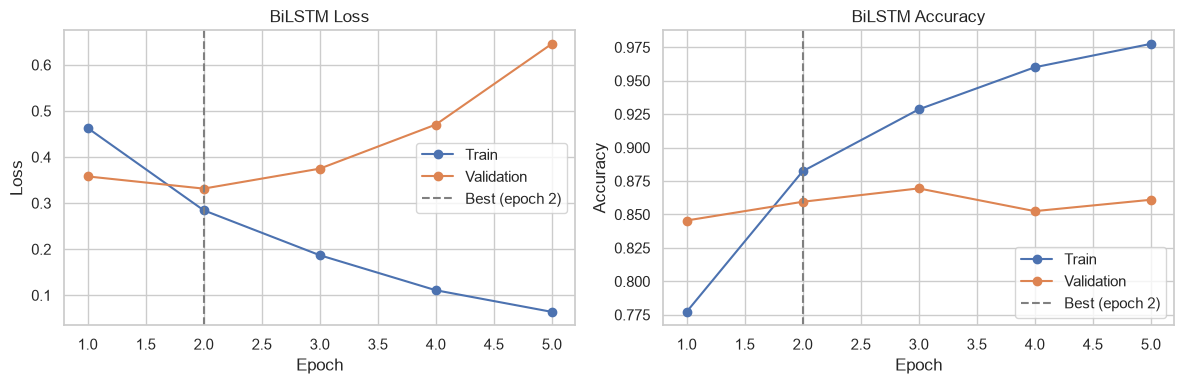

In [18]:
best_epoch = int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in [(axes[0], "loss", "Loss"), (axes[1], "acc", "Accuracy")]:
    ax.plot(history_df["epoch"], history_df[f"train_{metric}"], marker="o", label="Train")
    ax.plot(history_df["epoch"], history_df[f"val_{metric}"], marker="o", label="Validation")
    ax.axvline(best_epoch, color="gray", linestyle="--", label=f"Best (epoch {best_epoch})")
    ax.set(title=f"BiLSTM {title}", xlabel="Epoch", ylabel=title)
    ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "bilstm_training_curves.png", dpi=150)
plt.show()

## 9. Test-set evaluation

The best checkpoint is reloaded **through the same inference pipeline the app uses** (`src/inference.py`) and
evaluated once on the held-out test split. Metrics are saved to `reports/metrics_bilstm.json` for the benchmark.

In [19]:
bilstm_metrics = evaluate_predictor("BiLSTM", test_df["text"].tolist(), test_df["label"].tolist())
pd.Series(bilstm_metrics, name="BiLSTM (test)").round(4).to_frame()


=== BiLSTM ===
              precision    recall  f1-score   support

    Negative     0.8812    0.8460    0.8633      1000
    Positive     0.8519    0.8860    0.8686      1000

    accuracy                         0.8660      2000
   macro avg     0.8666    0.8660    0.8659      2000
weighted avg     0.8666    0.8660    0.8659      2000



,BiLSTM (test)
accuracy,0.8660
precision,0.8666
recall,0.8660
f1,0.8659


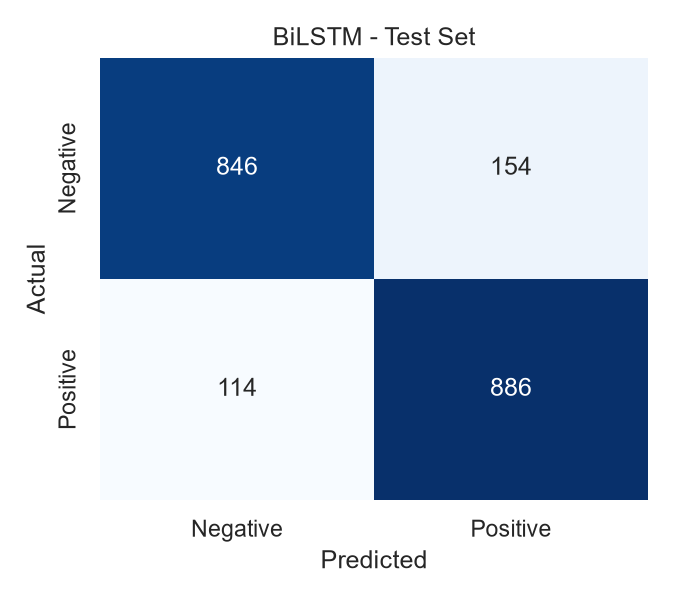

In [20]:
display(Image(filename=str(config.FIGURES_DIR / "confusion_matrix_bilstm.png"), width=380))

## 10. Sanity check with the CS flagging pipeline

In [21]:
CASES = [
    ("Positive review", "The product is excellent. Great quality and fast delivery!"),
    ("Negative, not urgent", "The product quality is disappointing. I don't really like it."),
    ("Negative + keyword", "This item looks fake and I want a refund immediately."),
    ("Keyword, positive", "The refund process was simple and the support team was great."),
    ("Acceptance test", "The product arrived completely broken and smells dangerous, I want a refund now!"),
]


def run_cases(model_name: str) -> pd.DataFrame:
    rows = []
    for case, text in CASES:
        result = analyze_review(text, model_name)
        rows.append({
            "case": case,
            "review": text,
            "sentiment": result.prediction.sentiment,
            "confidence": f"{result.prediction.confidence:.1%}",
            "keywords": ", ".join(result.flag.matched_keywords) or "-",
            "cs_flag": result.flag.label,
        })
    return pd.DataFrame(rows)

In [22]:
run_cases("BiLSTM")

,case,review,sentiment,confidence,keywords,cs_flag
0,Positive review,The product is excellent. Great quality and fa...,Positive,99.8%,-,✅ Normal
1,"Negative, not urgent",The product quality is disappointing. I don't ...,Negative,99.8%,-,✅ Normal
2,Negative + keyword,This item looks fake and I want a refund immed...,Negative,99.4%,"fake, refund",🔴 URGENT: TRANSFER TO CS
3,"Keyword, positive",The refund process was simple and the support ...,Positive,97.1%,refund,✅ Normal
4,Acceptance test,The product arrived completely broken and smel...,Negative,86.5%,"broken, dangerous, refund",🔴 URGENT: TRANSFER TO CS


## Summary

- A balanced 20k-review dataset was built and split 16k / 2k / 2k (train / val / test); the splits are saved
  in `data/processed/` and reused by notebook 02.
- The BiLSTM baseline is saved to `models/bilstm_best.pt` together with its vocabulary, so the app can load it
  without this notebook.
- Test metrics are in `reports/metrics_bilstm.json`; the side-by-side benchmark with DistilBERT is in
  notebook 02.